# Compute metrics

F1, recall, precision, mean IoU, mean Dice, PQ

Save metrics as:

results/experiment_metrics.csv


In [ ]:
1+1

2

In [2]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy
import skimage
import scipy
import basicpy
from tqdm import tqdm

import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')

from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl
from util import postprocessing as pp

%load_ext autoreload
%autoreload 2

In [3]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')
# organoid_sam = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


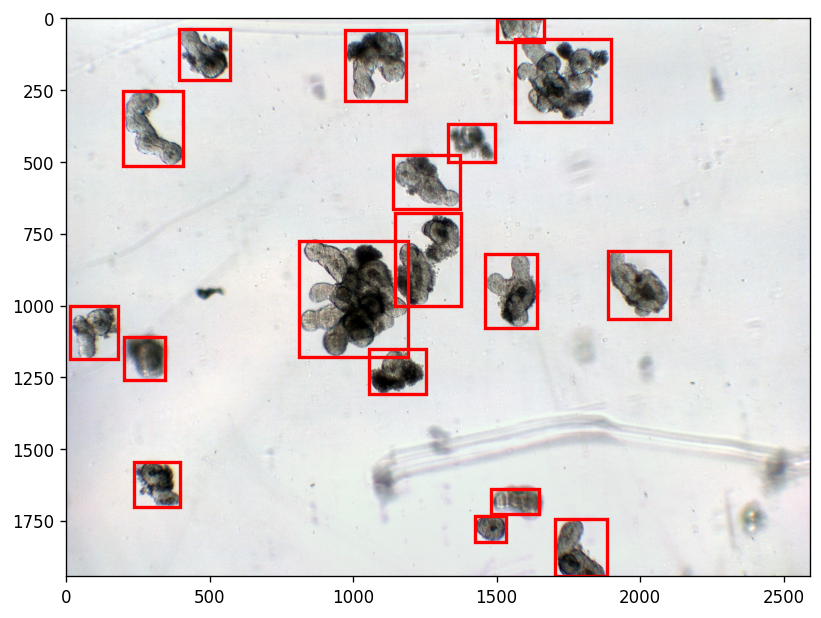

In [4]:
ds = dl.OrganoID(split='test_only_mouse')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

In [5]:
split = 'test'
pred_folder = Path(f'/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM2_large/{split}/{str(ds)}_{ds.split}/DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46')
pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, f'{str(ds)}_{ds.split}', pred_folder, im, im_ID)

In [6]:
pred_masks.shape

(400, 1944, 2592)

In [7]:
(pred_masks.sum(axis=(1, 2)) < 100).sum()

0

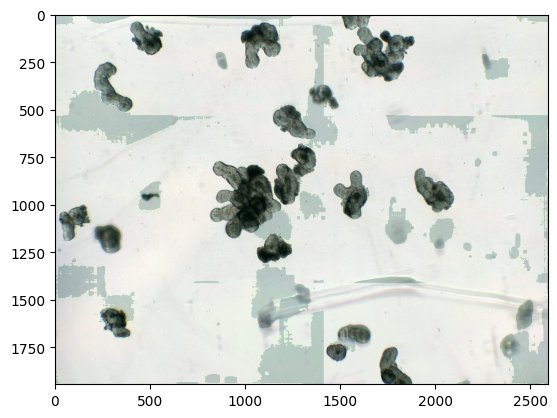

In [8]:
plt.imshow(im)
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255, alpha=0.2, cmap='YlGn')

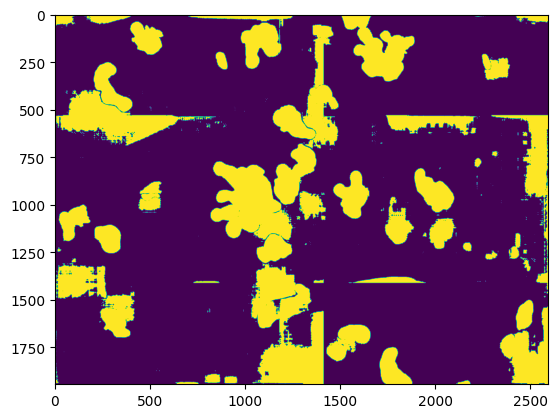

In [9]:
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255)

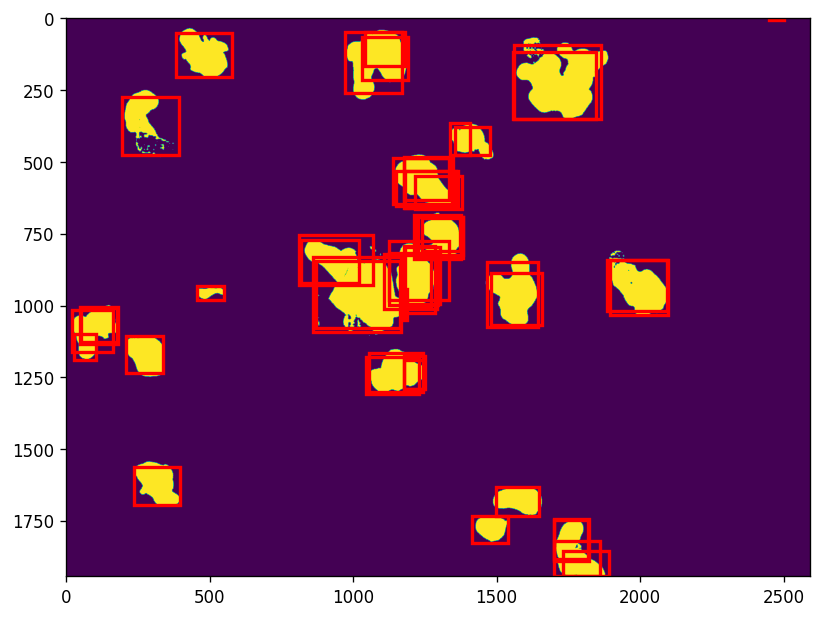

In [10]:
plot_boxes(np.any(pred_masks[pred_scores > 0.9], axis=0).astype(int) * 255, pred_boxes[pred_scores > 0.9], format='yxyx_px')
# plt.imshow(im)

## Tune threshold

In [11]:

# NMS threshold
from tqdm import tqdm

nms_thres = 0.5


experiment_name = 'sam_variants'
experiment = [
    # ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.37', 'MedSAM_last', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.42', 'MicroSAM_huge_last', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.55', 'MicroSAM_large_last', 'val', dl.OrganoID(split='val')),
    ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46', 'SAM2_large_last', 'val', dl.OrganoID(split='val')),
    # ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.22', 'SAM_base_last', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.82', 'MicroSAM_base_last', 'val', dl.OrganoID(split='val')),
    # ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.76', 'CellSAM_last', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'SAM_large_last', 'val', dl.OrganoID(split='val')),

    # ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=299-val_loss=11.35', 'MedSAM_best', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=199-val_loss=8.26', 'MicroSAM_huge_best', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=249-val_loss=8.47', 'MicroSAM_large_best', 'val', dl.OrganoID(split='val')),
    ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=7.18', 'SAM2_large_best', 'val', dl.OrganoID(split='val')),
    # ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=8.02', 'SAM_base_best', 'val', dl.OrganoID(split='val')),
    # ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=399-val_loss=8.80', 'MicroSAM_base_best', 'val', dl.OrganoID(split='val')),
    # ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=499-val_loss=11.76', 'CellSAM_best', 'val', dl.OrganoID(split='val')),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'SAM_large_best', 'val', dl.OrganoID(split='val')),
]


df = []


# df_partial = pd.read_csv(results_dir / f'thres_tuning_{experiment_name}_partial.csv')

for backbone, ckpt_name, model_name, split, test_data in experiment:
    # if ckpt_name in df_partial['ckpt_name'].unique().flatten().tolist():
    #     print('skipping')
    #     continue

    ds_name = f'{str(test_data)}_{test_data.split}'
    
    pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
    for im, mask, boxes, im_path, im_ID in tqdm(test_data):
        gt_masks = pp.convert_mask_to_binary(mask)

        # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
        # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
        # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
        # pred_boxes = pred_boxes[:min_shape]
        # pred_masks = pred_masks[:min_shape]
        # pred_scores = pred_scores[:min_shape]

        # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)
        pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)

        print(pred_boxes.shape, boxes.shape)

        keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
        pred_boxes = pred_boxes[keep_masks]
        pred_masks = pred_masks[keep_masks]
        pred_scores = pred_scores[keep_masks]
        
        # print(pred_boxes.shape, boxes.shape)

        # Filter most unrealistic ones
        # lowest_score = 0.5
        sorted_scores = np.sort(pred_scores, axis=None)
        if len(sorted_scores) < 300:
            lowest_score = 0.0
        else:
            lowest_score = np.round(sorted_scores[-300], decimals=2) 
        print(lowest_score)
        if lowest_score > 0.95:
            print('\n##### Skipping evaluation due to very high score threshold. #####\n')
            continue

        pred_boxes = pred_boxes[pred_scores >= lowest_score]
        pred_masks = pred_masks[pred_scores >= lowest_score]
        pred_scores = pred_scores[pred_scores >= lowest_score]
        
        # print(pred_boxes.shape, boxes.shape)

        iou_matrix_detection = pp.compute_iou_matrix_detection(pred_boxes, gt_boxes=boxes)
        # print('after det')
        iou_matrix_segmentation = pp.compute_iou_matrix_segmentation(pred_masks, gt_masks)
        # print('after seg')
        
        for confidence_thres in tqdm(np.arange(0.0, 1.0, 0.01)): 
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            _pred_boxes = pred_boxes[pred_scores >= confidence_thres]
            _pred_scores = pred_scores[pred_scores >= confidence_thres]
            _iou_matrix_detection = iou_matrix_detection[pred_scores >= confidence_thres]
            _iou_matrix_segmentation = iou_matrix_segmentation[pred_scores >= confidence_thres]
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(_pred_boxes, _pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                _iou_matrix_detection = _iou_matrix_detection[kept_indices]
                _iou_matrix_segmentation = _iou_matrix_segmentation[kept_indices]

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation_from_iou_matrix(
                    iou_matrix=_iou_matrix_segmentation, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'segmentation', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection_from_iou_matrix(
                    iou_matrix=_iou_matrix_detection, iou_threshold=0.5
                )
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID,
                            'detection', backbone, ckpt_name, model_name, f'{confidence_thres:.2f}',
                            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
            del _pred_boxes
            del _pred_scores
            del _iou_matrix_detection
            del _iou_matrix_segmentation
        del pred_boxes
        del pred_masks
        del pred_scores
    df_partial = pd.DataFrame(data=df, columns=[
        'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
        'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
    ])
    df_partial.to_csv(results_dir / f'thres_tuning_{experiment_name}_partial2.csv')

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])

# df = pd.concat([df, df_partial], axis=0, ignore_index=True)

df.to_csv(results_dir / f'thres_tuning_{experiment_name}_2.csv')
df

  0%|                                                                                  | 0/14 [00:00<?, ?it/s]

0.0


  7%|█████▏                                                                   | 1/14 [02:56<38:20, 177.00s/it]

0.0


 14%|██████████▍                                                              | 2/14 [04:26<25:06, 125.51s/it]

...

0.02


 93%|███████████████████████████████████████████████████████████████████▊     | 13/14 [06:08<00:32, 32.03s/it]

0.02


100%|█████████████████████████████████████████████████████████████████████████| 14/14 [06:32<00:00, 28.06s/it]


,exp_name,testset,im_ID,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,sam_variants,OrganoID_val,0,segmentation,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_last,0.00,74,704,21,0.132797,0.095116,0.778947,0.169530,0.783324,0.874365
1,sam_variants,OrganoID_val,0,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_last,0.00,74,704,21,0.000000,0.095116,0.778947,0.169530,0.730091,0.000000
2,sam_variants,OrganoID_val,0,segmentation,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_last,0.01,64,54,31,0.473960,0.542373,0.673684,0.600939,0.788699,0.877960
3,sam_variants,OrganoID_val,0,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_last,0.01,65,53,30,0.000000,0.550847,0.684211,0.610329,0.735171,0.000000
4,sam_variants,OrganoID_val,0,segmentation,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_last,0.02,63,50,32,0.479062,0.557522,0.663158,0.605769,0.790832,0.879340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,sam_variants,OrganoID_val,7,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.97,28,13,24,0.000000,0.682927,0.538462,0.602151,0.751089,0.000000
5196,sam_variants,OrganoID_val,7,segmentation,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.98,27,11,25,0.470086,0.710526,0.519231,0.600000,0.783477,0.872906
5197,sam_variants,OrganoID_val,7,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.98,27,11,25,0.000000,0.710526,0.519231,0.600000,0.747069,0.000000
5198,sam_variants,OrganoID_val,7,segmentation,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.99,14,7,38,0.310846,0.666667,0.269231,0.383562,0.810419,0.891835


In [12]:

df_partial = pd.read_csv(results_dir / f'thres_tuning_{experiment_name}_partial.csv')

In [13]:
df = pd.concat([df, df_partial], axis=0, ignore_index=True)

In [14]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres'], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,confidence_thres,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,sam_variants,OrganoID_val,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.0,0.000000,0.170730,0.482728,0.236147,0.709897,0.000000
1,sam_variants,OrganoID_val,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.01,0.000000,0.170730,0.482728,0.236147,0.709897,0.000000
2,sam_variants,OrganoID_val,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.02,0.000000,0.170730,0.482728,0.236147,0.709897,0.000000
3,sam_variants,OrganoID_val,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.03,0.000000,0.170730,0.482728,0.236147,0.709897,0.000000
4,sam_variants,OrganoID_val,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.04,0.000000,0.171106,0.482728,0.236659,0.709897,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,sam_variants,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_last,0.95,0.469789,0.611429,0.588786,0.598760,0.780712,0.871645
3196,sam_variants,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_last,0.96,0.467148,0.624967,0.573394,0.596768,0.779035,0.870559
3197,sam_variants,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_last,0.97,0.465668,0.644280,0.550746,0.593154,0.781442,0.872096
3198,sam_variants,OrganoID_val,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_last,0.98,0.458601,0.672914,0.517509,0.583515,0.782145,0.872427


In [15]:
det_df = metrics.loc[metrics.metric_type == 'detection']
det_df_max = det_df.groupby(['model_name', 'ckpt_name'], as_index=False).agg(
    max_f1 = ('f1_score_mean', 'max')
    #lambda x: x[x['f1_score_mean'] == x['f1_score_mean'].max(), 'confidence_thres'].item()
)
det_df = det_df.join(det_df_max.set_index(['model_name', 'ckpt_name']), on=['model_name', 'ckpt_name'], how='left')
best_thres_df = det_df.loc[det_df['f1_score_mean'] == det_df['max_f1'], ['model_name', 'confidence_thres', 'max_f1']]
best_thres_df

,model_name,confidence_thres,max_f1
79,CellSAM_best,0.79,0.412132
179,CellSAM_last,0.79,0.412132
283,MedSAM_best,0.83,0.416560
381,MedSAM_last,0.81,0.410412
493,MicroSAM_base_best,0.93,0.545812
590,MicroSAM_base_last,0.9,0.549211
689,MicroSAM_huge_best,0.89,0.554066
786,MicroSAM_huge_last,0.86,0.552367
886,MicroSAM_large_best,0.86,0.538839
994,MicroSAM_large_last,0.94,0.538195


In [16]:
best_thres_df.to_csv(results_dir / 'best_thres_df_sam_variants_backup.csv')

# Predict

boxes, scores and masks are saved in a folder called 'organoid_sam/patch_predictions/backbone/trainvaltest/dataset_name/checkpoint_name/image_ID/boxes_{i}.npy'

In [17]:
best_thres_df

,model_name,confidence_thres,max_f1
79,CellSAM_best,0.79,0.412132
179,CellSAM_last,0.79,0.412132
283,MedSAM_best,0.83,0.416560
381,MedSAM_last,0.81,0.410412
493,MicroSAM_base_best,0.93,0.545812
590,MicroSAM_base_last,0.9,0.549211
689,MicroSAM_huge_best,0.89,0.554066
786,MicroSAM_huge_last,0.86,0.552367
886,MicroSAM_large_best,0.86,0.538839
994,MicroSAM_large_last,0.94,0.538195


In [44]:

# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment_name = 'sam_variants'
experiment = [
    # ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.37', 'MedSAM_last'),
    # ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.42', 'MicroSAM_huge_last'),
    # ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.55', 'MicroSAM_large_last'),
    # ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.46', 'SAM2_large_last'),
    # ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.22', 'SAM_base_last'),
    # ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=8.82', 'MicroSAM_base_last'),
    # ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=11.76', 'CellSAM_last'),
    # ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-last_epoch=499-val_loss=7.90', 'SAM_large_last'),

    ('MedSAM', 'DetectionHead_MedSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=299-val_loss=11.35', 'MedSAM_best'),
    ('MicroSAM_huge', 'DetectionHead_MicroSAM_huge_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=199-val_loss=8.26', 'MicroSAM_huge_best'),
    ('MicroSAM_large', 'DetectionHead_MicroSAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=249-val_loss=8.47', 'MicroSAM_large_best'),
    ('SAM2_large', 'DetectionHead_SAM2_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=7.18', 'SAM2_large_best'),
    ('SAM_base', 'DetectionHead_SAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=99-val_loss=8.02', 'SAM_base_best'),
    ('MicroSAM_base', 'DetectionHead_MicroSAM_base_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=399-val_loss=8.80', 'MicroSAM_base_best'),
    ('CellSAM', 'DetectionHead_CellSAM_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=499-val_loss=11.76', 'CellSAM_best'),
    ('SAM_large', 'DetectionHead_SAM_large_OrganoID_train_finetune_specialist_pre_OI_False_32_500-best_epoch=149-val_loss=7.74', 'SAM_large_best'),
]


df = []
for split, test_data in [('test', dl.OrganoID(split='test')),
                    ('test', dl.OrganoID(split='test_Lung')),
                    ('test', dl.OrganoID(split='test_ACC')),
                    ('test', dl.OrganoID(split='test_C')),
                    ('test', dl.OrganoID(split='test_only_mouse'))]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = float(best_thres_df.loc[best_thres_df['model_name'] == model_name, 'confidence_thres'].item())
        print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = pp.organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            gt_masks = pp.convert_mask_to_binary(mask)

            pred_boxes, pred_scores, pred_masks, pred_patch_numbers, pred_offsets = pp.get_predictions(split, ds_name, pred_base, im, im_ID)
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_patch_numbers = pred_patch_numbers[pred_scores >= optimal_thres]
            pred_offsets = pred_offsets[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]


            keep_masks = pred_masks.sum(axis=(1, 2)) >= 100
            pred_boxes = pred_boxes[keep_masks]
            pred_masks = pred_masks[keep_masks]
            pred_patch_numbers = pred_patch_numbers[keep_masks]
            pred_offsets = pred_offsets[keep_masks]
            pred_scores = pred_scores[keep_masks]
            
            
            # TODO: Remove boxes at patch borders

            kept_indices = pp.non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # print('after nms')

            if len(kept_indices) != 0:
                pred_boxes = pred_boxes[kept_indices]
                pred_masks = pred_masks[kept_indices]
                pred_patch_numbers = pred_patch_numbers[kept_indices]
                pred_offsets = pred_offsets[kept_indices]
                pred_scores = pred_scores[kept_indices]

                pred_masks, pred_boxes, pred_scores = pp.stitch(pred_masks, 
                                                                pred_patch_numbers, 
                                                                pred_offsets, 
                                                                pred_boxes, 
                                                                pred_scores)

                assert pred_boxes.ndim == 2, pred_boxes.shape
                assert pred_boxes.shape[1] == 4, pred_boxes.shape
                assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
                assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_segmentation(pred_masks=pred_masks, 
                                                                                                                       gt_masks=gt_masks, 
                                                                                                                       iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
                tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = pp.compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                    gt_boxes=boxes, 
                                                                                                                    iou_threshold=0.5)
                df.append([experiment_name, 
                           f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                           'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                           tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
                
    df_partial = pd.DataFrame(data=df, columns=[
        'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
        'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
    ])
    df_partial.to_csv(results_dir / f'organoID_test_{experiment_name}_partial_results.csv')
    del df_partial

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres.csv')
df

0.83


100%|██████████████████████████████████████████████████████████████████| 10/10 [02:22<00:00, 14.29s/it]


0.89


100%|██████████████████████████████████████████████████████████████████| 10/10 [03:01<00:00, 18.20s/it]


0.86


...

0.79


100%|████████████████████████████████████████████████████████████████████| 4/4 [00:27<00:00,  6.91s/it]


0.83


100%|████████████████████████████████████████████████████████████████████| 4/4 [01:37<00:00, 24.49s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,sam_variants,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.83,6,95,174,0.025789,0.059406,0.033333,0.042705,0.603886,0.748743
1,sam_variants,OrganoID_test,PDAC1,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.83,33,68,147,0.000000,0.326733,0.183333,0.234875,0.731285,0.000000
2,sam_variants,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.83,13,151,66,0.065410,0.079268,0.164557,0.106996,0.611329,0.755933
3,sam_variants,OrganoID_test,PDAC10,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.83,49,115,30,0.000000,0.298780,0.620253,0.403292,0.685099,0.000000
4,sam_variants,OrganoID_test,PDAC2,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.83,38,47,16,0.401221,0.447059,0.703704,0.546763,0.733812,0.842661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,sam_variants,OrganoID_test_mouse,b_image0009,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.83,16,9,2,0.000000,0.640000,0.888889,0.744186,0.753438,0.000000
508,sam_variants,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.83,65,95,17,0.417067,0.406250,0.792683,0.537190,0.776386,0.868375
509,sam_variants,OrganoID_test_mouse,image0016,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.83,49,111,33,0.000000,0.306250,0.597561,0.404959,0.689775,0.000000
510,sam_variants,OrganoID_test_mouse,image0017,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.83,17,9,1,0.636094,0.653846,0.944444,0.772727,0.823180,0.897791


In [4]:
df = pd.read_csv(results_dir / f'organoID_test_sam_variants_correct_conf_thres.csv')

In [5]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,sam_variants,OrganoID_test,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.000000,0.391576,0.523409,0.419248,0.695949,0.000000
1,sam_variants,OrganoID_test,detection,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.000000,0.410317,0.532324,0.437567,0.699086,0.000000
2,sam_variants,OrganoID_test,detection,MicroSAM_base,DetectionHead_MicroSAM_base_OrganoID_train_fin...,MicroSAM_base_best,0.000000,0.637448,0.700531,0.648689,0.776243,0.000000
3,sam_variants,OrganoID_test,detection,MicroSAM_huge,DetectionHead_MicroSAM_huge_OrganoID_train_fin...,MicroSAM_huge_best,0.000000,0.538538,0.699972,0.598123,0.749877,0.000000
4,sam_variants,OrganoID_test,detection,MicroSAM_large,DetectionHead_MicroSAM_large_OrganoID_train_fi...,MicroSAM_large_best,0.000000,0.532933,0.714555,0.589827,0.751401,0.000000
5,sam_variants,OrganoID_test,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.000000,0.619494,0.759489,0.664268,0.741968,0.000000
6,sam_variants,OrganoID_test,detection,SAM_base,DetectionHead_SAM_base_OrganoID_train_finetune...,SAM_base_best,0.000000,0.491217,0.653879,0.541455,0.717645,0.000000
7,sam_variants,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.000000,0.477901,0.738272,0.565137,0.746856,0.000000
8,sam_variants,OrganoID_test,segmentation,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.197018,0.255755,0.373716,0.285437,0.660151,0.789437
9,sam_variants,OrganoID_test,segmentation,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.222629,0.289107,0.381499,0.310962,0.676285,0.801096


In [ ]:
metrics.to_csv(results_dir / f'organoID_test_{experiment_name}_correct_conf_thres_aggregated.csv')
metrics.head(40)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,sam_variants,OrganoID_test,detection,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.000000,0.369353,0.554990,0.417705,0.692609,0.000000
1,sam_variants,OrganoID_test,detection,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.000000,0.377612,0.553270,0.427412,0.695541,0.000000
2,sam_variants,OrganoID_test,detection,MicroSAM_base,DetectionHead_MicroSAM_base_OrganoID_train_fin...,MicroSAM_base_best,0.000000,0.618097,0.708426,0.640991,0.774022,0.000000
3,sam_variants,OrganoID_test,detection,MicroSAM_huge,DetectionHead_MicroSAM_huge_OrganoID_train_fin...,MicroSAM_huge_best,0.000000,0.485900,0.714084,0.570876,0.745803,0.000000
4,sam_variants,OrganoID_test,detection,MicroSAM_large,DetectionHead_MicroSAM_large_OrganoID_train_fi...,MicroSAM_large_best,0.000000,0.485724,0.725081,0.566257,0.750353,0.000000
5,sam_variants,OrganoID_test,detection,SAM2_large,DetectionHead_SAM2_large_OrganoID_train_finetu...,SAM2_large_best,0.000000,0.588062,0.767384,0.648768,0.740723,0.000000
6,sam_variants,OrganoID_test,detection,SAM_base,DetectionHead_SAM_base_OrganoID_train_finetune...,SAM_base_best,0.000000,0.465255,0.661774,0.529736,0.716253,0.000000
7,sam_variants,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrganoID_train_finetun...,SAM_large_best,0.000000,0.439293,0.748799,0.541192,0.745823,0.000000
8,sam_variants,OrganoID_test,segmentation,CellSAM,DetectionHead_CellSAM_OrganoID_train_finetune_...,CellSAM_best,0.186496,0.229965,0.373716,0.269570,0.660151,0.789437
9,sam_variants,OrganoID_test,segmentation,MedSAM,DetectionHead_MedSAM_OrganoID_train_finetune_s...,MedSAM_best,0.208515,0.252787,0.381499,0.291103,0.676285,0.801096


In [ ]:
pq_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['CellSAM_best', 'MedSAM_best', 'MicroSAM_base_best', 'MicroSAM_large_best', 'MicroSAM_huge_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
pq_metrics.to_csv(results_dir / 'ablation_SAM_variants_PQ.csv')
pq_metrics #.loc[['MicroSAM_base_best', 'SAM2_large_best', 'SAM_large_best', 'SAM_base_best'], :]

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
CellSAM_best,0.186496,0.212899,0.246490,0.430173,0.015023
MedSAM_best,0.208515,0.254752,0.247257,0.398524,0.121487
MicroSAM_base_best,0.526908,0.566320,0.529796,0.760263,0.371441
MicroSAM_large_best,0.456348,0.488720,0.588228,0.690542,0.408004
MicroSAM_huge_best,0.448153,0.516276,0.474012,0.666965,0.379354
SAM_base_best,0.475296,0.589577,0.419737,0.733356,0.583274
SAM_large_best,0.480840,0.616347,0.509040,0.783678,0.542728
SAM2_large_best,0.546705,0.557548,0.593757,0.727489,0.457462


In [13]:
pq_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
).loc[['CellSAM_best', 'MedSAM_best', 'MicroSAM_base_best', 'MicroSAM_large_best', 'MicroSAM_huge_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
pq_metrics.round(decimals=3).to_csv(results_dir / 'ablation_SAM_variants_PQ.csv')
pq_metrics.round(decimals=3) #.loc[['MicroSAM_base_best', 'SAM2_large_best', 'SAM_large_best', 'SAM_base_best'], :]

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
CellSAM_best,0.197,0.214,0.251,0.446,0.015
MedSAM_best,0.223,0.255,0.257,0.411,0.121
MicroSAM_base_best,0.532,0.566,0.537,0.760,0.371
MicroSAM_large_best,0.474,0.489,0.588,0.692,0.408
MicroSAM_huge_best,0.471,0.527,0.507,0.693,0.379
SAM_base_best,0.487,0.594,0.436,0.736,0.583
SAM_large_best,0.500,0.618,0.555,0.792,0.543
SAM2_large_best,0.560,0.558,0.605,0.740,0.457


In [ ]:
f1_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
f1_metrics.to_csv(results_dir / 'ablation_SAM_variants_F1_subset.csv')
f1_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.665814,0.687263,0.655538,0.879190,0.512109
SAM_base_best,0.597220,0.685502,0.502781,0.833945,0.706133
SAM_large_best,0.591267,0.725582,0.595997,0.861216,0.665041
SAM2_large_best,0.682654,0.659888,0.715416,0.829858,0.585937


In [14]:
f1_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
f1_metrics.round(decimals=3).to_csv(results_dir / 'ablation_SAM_variants_F1_subset.csv')
f1_metrics.round(decimals=3)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.669,0.687,0.664,0.877,0.512
SAM_base_best,0.611,0.690,0.522,0.837,0.706
SAM_large_best,0.612,0.726,0.649,0.871,0.665
SAM2_large_best,0.698,0.660,0.729,0.844,0.586


In [ ]:
mean_iou_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='mean_iou_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
mean_iou_metrics.to_csv(results_dir / 'ablation_SAM_variants_Mean_IoU_subset.csv')
mean_iou_metrics

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.789321,0.817503,0.808309,0.863387,0.713780
SAM_base_best,0.788577,0.857958,0.831899,0.877994,0.825246
SAM_large_best,0.809683,0.849978,0.853562,0.909865,0.814600
SAM2_large_best,0.798173,0.844022,0.829588,0.875867,0.780981


In [15]:
mean_iou_metrics = metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='mean_iou_mean'
).loc[['MicroSAM_base_best', 'SAM_base_best', 'SAM_large_best', 'SAM2_large_best'], :]
mean_iou_metrics.round(decimals=3).to_csv(results_dir / 'ablation_SAM_variants_Mean_IoU_subset.csv')
mean_iou_metrics.round(decimals=3)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
MicroSAM_base_best,0.793,0.818,0.808,0.865,0.714
SAM_base_best,0.789,0.858,0.832,0.878,0.825
SAM_large_best,0.812,0.852,0.854,0.910,0.815
SAM2_large_best,0.800,0.844,0.830,0.876,0.781


### Plots

In [24]:
metrics_orgasegment_ours = pd.read_csv(results_dir / f'organoID_test_orgasegment_comparison_correct_conf_thres_aggregated.csv')
metrics_orgasegment_ours.head(40)

,Unnamed: 0,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,0,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.000000,0.565898,0.470829,0.486638,0.715293,0.000000
1,1,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.000000,0.592947,0.488204,0.511908,0.712827,0.000000
2,2,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_best,0.000000,0.697032,0.468219,0.542019,0.735094,0.000000
3,3,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,NeurIPS_last,0.000000,0.713663,0.442126,0.528173,0.729683,0.000000
4,4,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_best,0.000000,0.717021,0.491438,0.547886,0.742746,0.000000
5,5,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_last,0.000000,0.689223,0.474995,0.529849,0.746580,0.000000
6,6,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.000000,0.693883,0.573620,0.599545,0.749804,0.000000
7,7,orgasegment_comparison,OrganoID_test,detection,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_last,0.000000,0.717243,0.511939,0.571156,0.763583,0.000000
8,8,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_best,0.467015,0.663297,0.559374,0.572911,0.814171,0.892117
9,9,orgasegment_comparison,OrganoID_test,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,no_pretraining_last,0.471971,0.670629,0.552170,0.578963,0.818058,0.894790


In [25]:
metrics_orgasegment_ours = metrics_orgasegment_ours[metrics_orgasegment_ours.metric_type=='segmentation']

In [26]:
metrics_orgasegment_ours = metrics_orgasegment_ours[metrics_orgasegment_ours.testset == 'OrganoID_test_Lung']

In [28]:
metrics_orgasegment_ours[metrics_orgasegment_ours.model_name == 'OI_and_NeurIPS_best']

,Unnamed: 0,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
62,62,orgasegment_comparison,OrganoID_test_Lung,segmentation,SAM_large,DetectionHead_SAM_large_OrgaSegment_train_fine...,OI_and_NeurIPS_best,0.737434,0.852472,0.797837,0.823282,0.894376,0.941056
